<a href="https://colab.research.google.com/github/gopika-vit/-AI-DS-/blob/main/Random_forest%2Cchi_square.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Top 10 Features (Random Forest Importance) ===
worst concave points    0.158955
worst area              0.146962
worst perimeter         0.085793
worst radius            0.078952
mean radius             0.077714
mean perimeter          0.074234
mean concave points     0.065869
mean concavity          0.054281
mean area               0.041657
worst concavity         0.031362
dtype: float64


/tmp/ipython-input-1819377362.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rf, y=top_rf.index, palette='Blues_r')


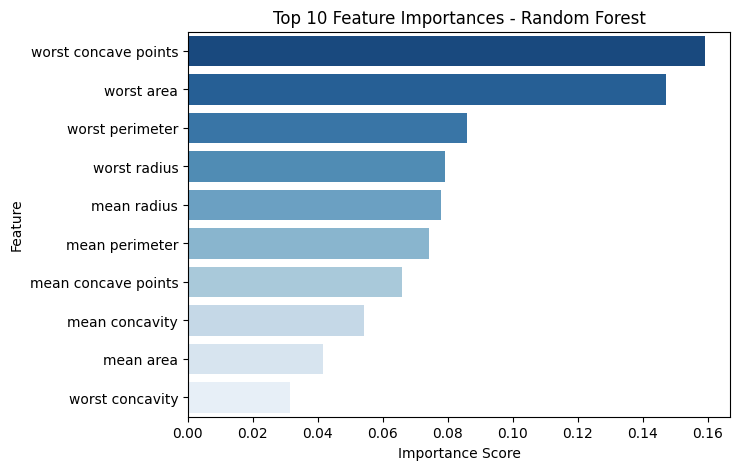


=== Top 10 Features (Chi-Square Test) ===
mean concave points     52.405743
worst concave points    46.341648
mean concavity          46.186395
worst area              35.043882
worst perimeter         34.438091
worst radius            34.124937
worst concavity         31.563031
mean area               29.328594
mean perimeter          26.528902
mean radius             24.897293
dtype: float64


/tmp/ipython-input-1819377362.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_chi2, y=top_chi2.index, palette='Greens_r')


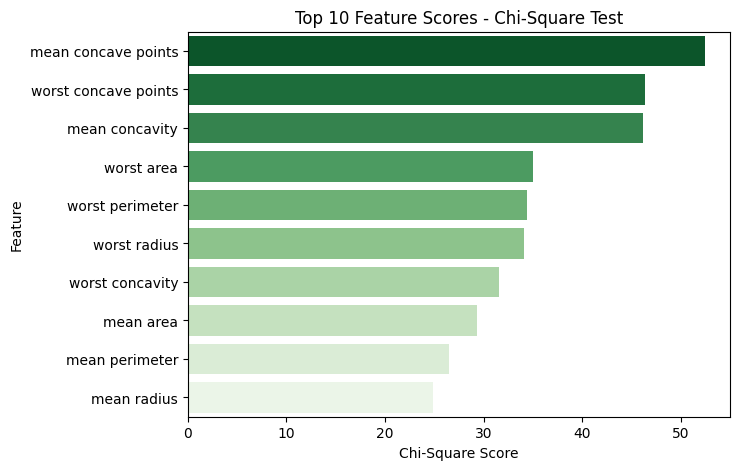

In [ ]:
# === Feature Selection using RandomForest & Chi-Square ===
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------------------------------------
# METHOD 1: Feature Importance using RandomForest
# -----------------------------------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get top 10 features
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_rf = importances.head(10)

print("\n=== Top 10 Features (Random Forest Importance) ===")
print(top_rf)

# Plot
plt.figure(figsize=(7,5))
sns.barplot(x=top_rf, y=top_rf.index, palette='Blues_r')
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# -----------------------------------------------------------
# METHOD 2: Feature Selection using Chi-Square
# -----------------------------------------------------------
# Chi-square requires non-negative values → normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

chi2_selector = SelectKBest(score_func=chi2, k=10)
chi2_selector.fit(X_scaled, y)

chi2_scores = pd.Series(chi2_selector.scores_, index=X.columns).sort_values(ascending=False)
top_chi2 = chi2_scores.head(10)

print("\n=== Top 10 Features (Chi-Square Test) ===")
print(top_chi2)

# Plot
plt.figure(figsize=(7,5))
sns.barplot(x=top_chi2, y=top_chi2.index, palette='Greens_r')
plt.title("Top 10 Feature Scores - Chi-Square Test")
plt.xlabel("Chi-Square Score")
plt.ylabel("Feature")
plt.show()